In [ ]:
import os
from PIL import Image
from IPython.display import display
import torch
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

from fakers import *

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Base transforms for baseline and standard extraction
base_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Heavy augmentation for Experiments to reduce "shortcut" learning
aug_transform = A.Compose([
    A.Resize(224, 224),
    A.ImageCompression(quality_range = (5, 20), p=0.5), # Compression
    A.GaussianBlur(blur_limit=(1, 3), p=0.5),           # Blur
    A.GaussNoise(std_range=(0.05, 0.1), p=0.5),         # Noise
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

## Full frame models

These models utilise entire extracted frames from the dataset in order to make its predictions.

In [3]:
gen = torch.Generator().manual_seed(42)

# fpp image datasets
fpp_frames_path = "../data/fpp-frame/" # change to appropriate directory
fpp_real_path = fpp_frames_path + "real/"
fpp_fake_path = fpp_frames_path + "fake/"

fpp_img_paths = [fpp_real_path + img_path for img_path in os.listdir(fpp_real_path)] + [fpp_fake_path + img_path for img_path in os.listdir(fpp_fake_path)]
fpp_img_labels = [0] * len(os.listdir(fpp_real_path)) + [1] * len(os.listdir(fpp_fake_path))

# celeb-df dataset
cdf_frames_path = "../data/celebdf-frame/" # change to appropriate directory. only using test set here.
cdf_real_path = cdf_frames_path + "real/"
cdf_fake_path = cdf_frames_path + "fake/"

cdf_img_paths = [cdf_real_path + img_path for img_path in os.listdir(cdf_real_path)] + [cdf_fake_path + img_path for img_path in os.listdir(cdf_fake_path)]
cdf_img_labels = [0] * len(os.listdir(cdf_real_path)) + [1] * len(os.listdir(cdf_fake_path))

# datasets and loaders with augmentation
fpp_wtrf_train_set, fpp_wtrf_val_set = random_split(DeepfakeImageDataset(fpp_img_paths, fpp_img_labels, transform=aug_transform), [0.8, 0.2], gen)
fpp_wtrf_train_loader = DataLoader(fpp_wtrf_train_set, 64, shuffle=True)
fpp_wtrf_val_loader = DataLoader(fpp_wtrf_val_set, 64, shuffle=True)

# datasets and loaders without augmentation
fpp_train_set, fpp_val_set = random_split(DeepfakeImageDataset(fpp_img_paths, fpp_img_labels, transform=base_transform), [0.8, 0.2], gen)
fpp_train_loader = DataLoader(fpp_train_set, 64, shuffle=True)
fpp_val_loader = DataLoader(fpp_val_set, 64, shuffle=True)

# celeb-df validation dataset
cdf_dataset = DeepfakeImageDataset(cdf_img_paths, cdf_img_labels, transform=base_transform)
cdf_dataloader = DataLoader(cdf_dataset, 64, shuffle=True)

In [4]:
experiment_results = {"Frame":{}, "Face":{}}

model_rgb = HybridDeepfakeDetector(mode='rgb').to(device)
state_dict = torch.load('../models/model_rgb_20260412_165619_8', weights_only=True)
model_rgb.load_state_dict(state_dict)
gap_rgb = evaluate_generalization_gap(model_rgb, fpp_val_loader, cdf_dataloader, 'rgb', device)
experiment_results["Frame"]['RGB Only'] = gap_rgb

model_aug = HybridDeepfakeDetector(mode='rgb').to(device)
state_dict = torch.load('../models/model_rgb_20260412_184726_9', weights_only=True)
model_aug.load_state_dict(state_dict)
gap_aug = evaluate_generalization_gap(model_aug, fpp_wtrf_val_loader, cdf_dataloader, 'rgb', device)
experiment_results["Frame"]['RGB + Augmentation'] = gap_aug

model_fft = HybridDeepfakeDetector(mode='fft').to(device)
state_dict = torch.load('../models/model_fft_20260412_203834_0', weights_only=True)
model_fft.load_state_dict(state_dict)
gap_fft = evaluate_generalization_gap(model_fft, fpp_val_loader, cdf_dataloader, 'fft', device)
experiment_results["Frame"]['FFT Only'] = gap_fft

model_hyb = HybridDeepfakeDetector(mode='hybrid').to(device)
state_dict = torch.load('../models/model_hybrid_20260412_213723_9', weights_only=True)
model_hyb.load_state_dict(state_dict)
gap_hyb = evaluate_generalization_gap(model_hyb, fpp_wtrf_val_loader, cdf_dataloader, 'hybrid', device)
experiment_results["Frame"]['Hybrid'] = gap_hyb

experiment_results

--- Model Setup [RGB] ---
In-domain (FF++)      : Acc=92.35%, F1=0.940, AUC=0.979
Cross-domain (CelebDF): Acc=60.10%, F1=0.619, AUC=0.642
GENERALIZATION GAP: 32.25%

--- Model Setup [RGB] ---
In-domain (FF++)      : Acc=82.30%, F1=0.862, AUC=0.906
Cross-domain (CelebDF): Acc=50.98%, F1=0.396, AUC=0.539
GENERALIZATION GAP: 31.33%

--- Model Setup [FFT] ---
In-domain (FF++)      : Acc=64.60%, F1=0.785, AUC=0.492
Cross-domain (CelebDF): Acc=50.00%, F1=0.667, AUC=0.417
GENERALIZATION GAP: 14.60%

--- Model Setup [HYBRID] ---
In-domain (FF++)      : Acc=82.38%, F1=0.869, AUC=0.905
Cross-domain (CelebDF): Acc=59.14%, F1=0.549, AUC=0.627
GENERALIZATION GAP: 23.24%



{'Frame': {'RGB Only': (0.3225474006116208,
   (0.9235474006116208, 0.601),
   (0.9403697078115683, 0.6187290969899666),
   (0.9792062315488134, 0.64168959375)),
  'RGB + Augmentation': (0.3132622324159021,
   (0.8230122324159022, 0.50975),
   (0.861749776052553, 0.39568567026194146),
   (0.9064049933516647, 0.539167375)),
  'FFT Only': (0.1460244648318043,
   (0.6460244648318043, 0.5),
   (0.7849512308406874, 0.6666666666666666),
   (0.4920022492875126, 0.41735112500000004)),
  'Hybrid': (0.23240175840978594,
   (0.8237767584097859, 0.591375),
   (0.8692940175786787, 0.5491656323265757),
   (0.9046015517085576, 0.6274652187499999))},
 'Face': {}}

## Face only models

And these models only consider the faces extracted from those frames in order to make a prediction.

In [5]:
gen = torch.Generator().manual_seed(42)

# fpp image datasets
fpp_frames_path = "../data/fpp-face/" # change to appropriate directory
fpp_real_path = fpp_frames_path + "real/"
fpp_fake_path = fpp_frames_path + "fake/"

fpp_img_paths = [fpp_real_path + img_path for img_path in os.listdir(fpp_real_path)] + [fpp_fake_path + img_path for img_path in os.listdir(fpp_fake_path)]
fpp_img_labels = [0] * len(os.listdir(fpp_real_path)) + [1] * len(os.listdir(fpp_fake_path))

# celeb-df dataset
cdf_frames_path = "../data/celebdf-face/" # change to appropriate directory. only using test set here.
cdf_real_path = cdf_frames_path + "real/"
cdf_fake_path = cdf_frames_path + "fake/"

cdf_img_paths = [cdf_real_path + img_path for img_path in os.listdir(cdf_real_path)] + [cdf_fake_path + img_path for img_path in os.listdir(cdf_fake_path)]
cdf_img_labels = [0] * len(os.listdir(cdf_real_path)) + [1] * len(os.listdir(cdf_fake_path))

# datasets and loaders with augmentation
fpp_wtrf_train_set, fpp_wtrf_val_set = random_split(DeepfakeImageDataset(fpp_img_paths, fpp_img_labels, transform=aug_transform), [0.8, 0.2], gen)
fpp_wtrf_train_loader = DataLoader(fpp_wtrf_train_set, 64, shuffle=True)
fpp_wtrf_val_loader = DataLoader(fpp_wtrf_val_set, 64, shuffle=True)

# datasets and loaders without augmentation
fpp_train_set, fpp_val_set = random_split(DeepfakeImageDataset(fpp_img_paths, fpp_img_labels, transform=base_transform), [0.8, 0.2], gen)
fpp_train_loader = DataLoader(fpp_train_set, 64, shuffle=True)
fpp_val_loader = DataLoader(fpp_val_set, 64, shuffle=True)

# celeb-df validation dataset
cdf_dataset = DeepfakeImageDataset(cdf_img_paths, cdf_img_labels, transform=base_transform)
cdf_dataloader = DataLoader(cdf_dataset, 64, shuffle=True)

In [6]:
model_rgb = HybridDeepfakeDetector(mode='rgb').to(device)
state_dict = torch.load('../models/model_rgb_20260416_091501_9', weights_only=True)
model_rgb.load_state_dict(state_dict)
gap_rgb = evaluate_generalization_gap(model_rgb, fpp_val_loader, cdf_dataloader, 'rgb', device)
experiment_results["Face"]['RGB Only'] = gap_rgb

model_aug = HybridDeepfakeDetector(mode='rgb').to(device)
state_dict = torch.load('../models/model_rgb_20260416_093803_9', weights_only=True)
model_aug.load_state_dict(state_dict)
gap_aug = evaluate_generalization_gap(model_aug, fpp_wtrf_val_loader, cdf_dataloader, 'rgb', device)
experiment_results["Face"]['RGB + Augmentation'] = gap_aug

model_fft = HybridDeepfakeDetector(mode='fft').to(device)
state_dict = torch.load('../models/model_fft_20260416_095640_8', weights_only=True)
model_fft.load_state_dict(state_dict)
gap_fft = evaluate_generalization_gap(model_fft, fpp_val_loader, cdf_dataloader, 'fft', device)
experiment_results["Face"]['FFT Only'] = gap_fft

model_hyb = HybridDeepfakeDetector(mode='hybrid').to(device)
state_dict = torch.load('../models/model_hybrid_20260416_102842_7', weights_only=True)
model_hyb.load_state_dict(state_dict)
gap_hyb = evaluate_generalization_gap(model_hyb, fpp_wtrf_val_loader, cdf_dataloader, 'hybrid', device)
experiment_results["Face"]['Hybrid'] = gap_hyb

experiment_results

--- Model Setup [RGB] ---
In-domain (FF++)      : Acc=98.55%, F1=0.989, AUC=0.999
Cross-domain (CelebDF): Acc=61.52%, F1=0.536, AUC=0.686
GENERALIZATION GAP: 37.02%

--- Model Setup [RGB] ---
In-domain (FF++)      : Acc=94.95%, F1=0.961, AUC=0.990
Cross-domain (CelebDF): Acc=64.28%, F1=0.610, AUC=0.709
GENERALIZATION GAP: 30.67%

--- Model Setup [FFT] ---
In-domain (FF++)      : Acc=81.78%, F1=0.867, AUC=0.898
Cross-domain (CelebDF): Acc=59.94%, F1=0.670, AUC=0.661
GENERALIZATION GAP: 21.84%

--- Model Setup [HYBRID] ---
In-domain (FF++)      : Acc=93.34%, F1=0.949, AUC=0.982
Cross-domain (CelebDF): Acc=69.47%, F1=0.675, AUC=0.774
GENERALIZATION GAP: 23.86%



{'Frame': {'RGB Only': (0.3225474006116208,
   (0.9235474006116208, 0.601),
   (0.9403697078115683, 0.6187290969899666),
   (0.9792062315488134, 0.64168959375)),
  'RGB + Augmentation': (0.3132622324159021,
   (0.8230122324159022, 0.50975),
   (0.861749776052553, 0.39568567026194146),
   (0.9064049933516647, 0.539167375)),
  'FFT Only': (0.1460244648318043,
   (0.6460244648318043, 0.5),
   (0.7849512308406874, 0.6666666666666666),
   (0.4920022492875126, 0.41735112500000004)),
  'Hybrid': (0.23240175840978594,
   (0.8237767584097859, 0.591375),
   (0.8692940175786787, 0.5491656323265757),
   (0.9046015517085576, 0.6274652187499999))},
 'Face': {'RGB Only': (0.3702017611026034,
   (0.9854517611026034, 0.61525),
   (0.9888693614528412, 0.5364457831325301),
   (0.9986544713651235, 0.6862085)),
  'RGB + Augmentation': (0.30671401225114847,
   (0.9494640122511485, 0.64275),
   (0.9614935822637106, 0.6097760786455488),
   (0.9899435551152361, 0.70851478125)),
  'FFT Only': (0.218389165390505

## Look at this graph

In [ ]:
# Examples of input data

frame = Image.open("../data/fpp-frame/fake/004_982_frame0000.jpg")
face = Image.open("../data/fpp-face/fake/004_982_frame0000.jpg")
freq_face = Image.fromarray(extract_fft(np.array(face)))

display(frame)
display(face)
display(freq_face)

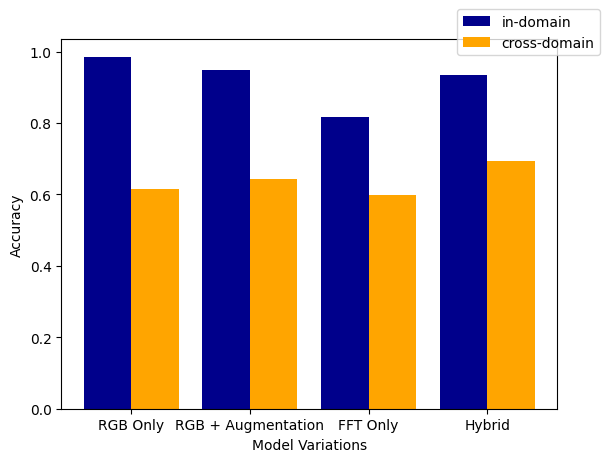

In [27]:
# In-domain and cross-domain accuracies across models

x = np.arange(4)
in_accs = [metrics[1][0] for _, metrics in experiment_results["Face"].items()]
cross_accs = [metrics[1][1] for _, metrics in experiment_results["Face"].items()]
labels = [label for label, _ in experiment_results["Face"].items()]

bar_width = 0.4

plt.bar(x-0.2, in_accs, bar_width, color="darkblue")
plt.bar(x+0.2, cross_accs, bar_width, color="orange")
plt.xticks(x, labels)
plt.xlabel("Model Variations")
plt.ylabel("Accuracy")
plt.legend(["in-domain", "cross-domain"], bbox_to_anchor=(1.1, 1.1), loc="upper right")
plt.show()

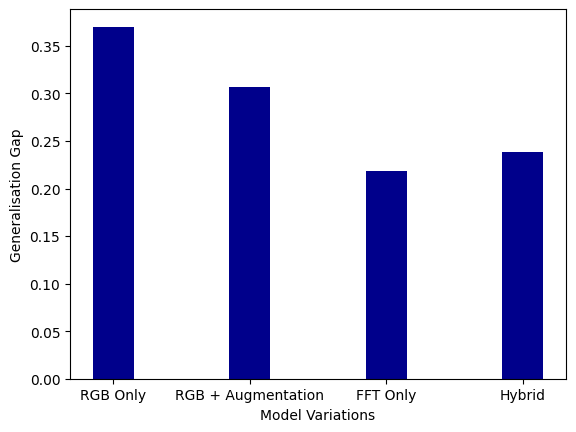

In [28]:
# Generalisation gap across models

x = np.arange(4)
gaps = [metrics[0] for _, metrics in experiment_results["Face"].items()]
labels = [label for label, _ in experiment_results["Face"].items()]

bar_width = 0.3

plt.bar(x, gaps, bar_width, color="darkblue")
plt.xticks(x, labels)
plt.xlabel("Model Variations")
plt.ylabel("Generalisation Gap")
plt.show()

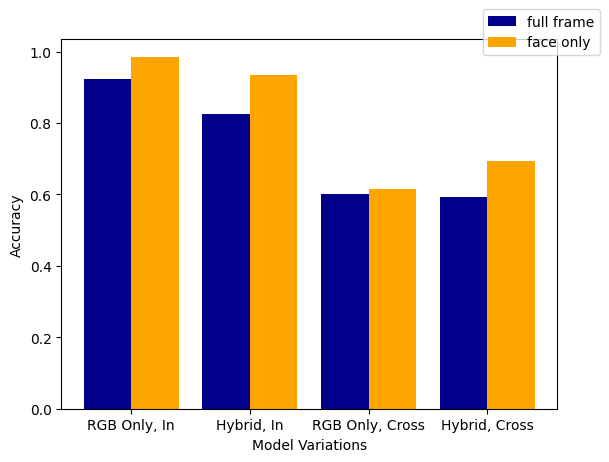

In [39]:
# Frame-face comparison

x = np.arange(4)
accs_frame = [experiment_results["Frame"]['RGB Only'][1][0], experiment_results["Frame"]['Hybrid'][1][0], experiment_results["Frame"]['RGB Only'][1][1], experiment_results["Frame"]['Hybrid'][1][1]]
accs_face = [experiment_results["Face"]['RGB Only'][1][0], experiment_results["Face"]['Hybrid'][1][0], experiment_results["Face"]['RGB Only'][1][1], experiment_results["Face"]['Hybrid'][1][1]]
labels = ["RGB Only, In", "Hybrid, In", "RGB Only, Cross", "Hybrid, Cross"]

bar_width = 0.4

plt.bar(x-0.2, accs_frame, bar_width, color="darkblue")
plt.bar(x+0.2, accs_face, bar_width, color="orange")
plt.xticks(x, labels)
plt.xlabel("Model Variations")
plt.ylabel("Accuracy")
plt.legend(["full frame", "face only"], bbox_to_anchor=(1.1, 1.1), loc="upper right")
plt.show()